In [ ]:
import os

# Install required libraries
!pip install -q kaggle plotly pandas numpy

print("Libraries installed successfully.")

Libraries installed successfully.


In [ ]:
import os
import pandas as pd
from pathlib import Path

# 1. Setup Kaggle configuration directory
KAG_DIR = Path.home() / '.kaggle'
KAG_DIR.mkdir(exist_ok=True)

print('Note: To download the dataset, ensure kaggle.json is in ' + str(KAG_DIR))

# 2. Create the project notebooks
notebook_files = ['01_EDA.ipynb', '02_Model_Training.ipynb', '03_Strategy_Simulator.ipynb']
for nb in notebook_files:
    if not os.path.exists(nb):
        with open(nb, 'w') as f:
            f.write('{"cells": [], "metadata": {}, "nbformat": 4, "nbformat_minor": 5}')
        print(f'Created: {nb}')

# 3. Download the F1 Pit Stop Strategy Dataset
# Replace 'dataset-slug' with the actual slug if known. Assuming 'rohanrao/formula-1-world-championship-1950-2020' as a proxy if 'F1 Pit Stop Strategy' is specific
dataset_slug = 'rohanrao/formula-1-world-championship-1950-2020' # Standard F1 dataset including pit stops

try:
    !kaggle datasets download -d {dataset_slug} --unzip -p ./data
    print('Dataset downloaded and unzipped successfully.')

    # 4. Verify files
    data_path = Path('./data')
    if data_path.exists():
        files = list(data_path.glob('*.csv'))
        print(f'Found {len(files)} CSV files: {[f.name for f in files]}')
        if files:
            df_test = pd.read_csv(files[0])
            print(f'Verified access to {files[0].name}. Shape: {df_test.shape}')
except Exception as e:
    print(f'Kaggle API error: {e}. Please ensure kaggle.json is uploaded.')

Note: To download the dataset, ensure kaggle.json is in /root/.kaggle
Created: 01_EDA.ipynb
Created: 02_Model_Training.ipynb
Created: 03_Strategy_Simulator.ipynb
Dataset URL: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020
License(s): CC0-1.0
100% 6.28M/6.28M [00:00<00:00, 141MB/s]

Dataset downloaded and unzipped successfully.
Found 14 CSV files: ['driver_standings.csv', 'drivers.csv', 'constructor_results.csv', 'seasons.csv', 'results.csv', 'circuits.csv', 'qualifying.csv', 'lap_times.csv', 'sprint_results.csv', 'races.csv', 'pit_stops.csv', 'status.csv', 'constructors.csv', 'constructor_standings.csv']
Verified access to driver_standings.csv. Shape: (34863, 7)


In [ ]:
import pandas as pd
import numpy as np

# Load datasets
pit_stops = pd.read_csv('./data/pit_stops.csv')
races = pd.read_csv('./data/races.csv')
drivers = pd.read_csv('./data/drivers.csv')
lap_times = pd.read_csv('./data/lap_times.csv')

# Merge pit stops with race and driver info
df_pit_stops_merged = pit_stops.merge(races[['raceId', 'year', 'name', 'circuitId']], on='raceId')
df_pit_stops_merged = df_pit_stops_merged.merge(drivers[['driverId', 'driverRef', 'code']], on='driverId')

print(f"Merged Pit Stop Data Shape: {df_pit_stops_merged.shape}")
display(df_pit_stops_merged.head())

# Quick check on lap times for a sample race to verify connectivity
sample_race_id = df_pit_stops_merged['raceId'].iloc[0]
df_laps_sample = lap_times[lap_times['raceId'] == sample_race_id]
print(f"Sample Lap Times for Race {sample_race_id} Shape: {df_laps_sample.shape}")

Merged Pit Stop Data Shape: (11371, 12)


,raceId,driverId,stop,lap,time,duration,milliseconds,year,name,circuitId,driverRef,code
0,841,153,1,1,17:05:23,26.898,26898,2011,Australian Grand Prix,1,alguersuari,ALG
1,841,30,1,1,17:05:52,25.021,25021,2011,Australian Grand Prix,1,michael_schumacher,MSC
2,841,17,1,11,17:20:48,23.426,23426,2011,Australian Grand Prix,1,webber,WEB
3,841,4,1,12,17:22:34,23.251,23251,2011,Australian Grand Prix,1,alonso,ALO
4,841,13,1,13,17:24:10,23.842,23842,2011,Australian Grand Prix,1,massa,MAS


Sample Lap Times for Race 841 Shape: (1083, 6)


In [ ]:
import plotly.express as px
import plotly.io as pio

# 1. Data Cleaning
# Convert duration to numeric, coerce errors to handle any malformed strings like '\N'
df_pit_stops_merged['duration_sec'] = pd.to_numeric(df_pit_stops_merged['duration'], errors='coerce')

# Fill missing durations using milliseconds if available
mask = df_pit_stops_merged['duration_sec'].isna()
df_pit_stops_merged.loc[mask, 'duration_sec'] = df_pit_stops_merged.loc[mask, 'milliseconds'] / 1000.0

# Drop rows where duration is still missing or clearly erroneous (e.g., > 1000 seconds for a pit stop)
df_pit_stops_cleaned = df_pit_stops_merged[df_pit_stops_merged['duration_sec'] < 200].dropna(subset=['duration_sec'])

# 2. Visualize Pit Stop Durations over Seasons
pio.templates.default = 'plotly_dark'

fig_durations = px.scatter(
    df_pit_stops_cleaned,
    x='year',
    y='duration_sec',
    color='duration_sec',
    color_continuous_scale='Reds',
    title='F1 Pit Stop Durations Over Seasons',
    labels={'year': 'Season', 'duration_sec': 'Duration (seconds)'},
    opacity=0.5
)

fig_durations.update_layout(
    title_font_size=24,
    font_family='Arial',
    plot_bgcolor='rgb(10, 10, 10)',
    paper_bgcolor='rgb(10, 10, 10)'
)

fig_durations.show()

print(f'Cleaned data contains {len(df_pit_stops_cleaned)} records.')

Cleaned data contains 10893 records.


In [ ]:
import plotly.graph_objects as go

# 1. Analyze Pit Stop Frequency by Circuit
# Calculate average stops per race for each circuit
circuit_stops = df_pit_stops_cleaned.groupby(['raceId', 'name']).size().reset_index(name='total_stops')
circuit_avg_stops = circuit_stops.groupby('name')['total_stops'].mean().sort_values(ascending=False).head(15).reset_index()

fig_circuit = px.bar(
    circuit_avg_stops,
    x='total_stops',
    y='name',
    orientation='h',
    title='Top 15 Circuits by Average Pit Stops per Race',
    labels={'total_stops': 'Avg Pit Stops', 'name': 'Circuit Name'},
    color='total_stops',
    color_continuous_scale='Reds'
)

fig_circuit.update_layout(yaxis={'categoryorder':'total ascending'})
fig_circuit.show()

# 2. Lap Time Consistency Analysis (Tyre Degradation Proxy)
# Filter lap times for the sample race (Race ID 841) and top 5 drivers by frequency
top_drivers = df_laps_sample['driverId'].value_counts().head(5).index
df_laps_filtered = df_laps_sample[df_laps_sample['driverId'].isin(top_drivers)].copy()

# Convert milliseconds to seconds for easier reading
df_laps_filtered['lap_time_sec'] = df_laps_filtered['milliseconds'] / 1000.0

fig_laps = px.line(
    df_laps_filtered,
    x='lap',
    y='lap_time_sec',
    color='driverId',
    title='Lap Time Trends: Race ID 841 (Top 5 Drivers)',
    labels={'lap': 'Lap Number', 'lap_time_sec': 'Lap Time (s)', 'driverId': 'Driver ID'},
    markers=True
)

fig_laps.update_layout(
    plot_bgcolor='rgb(10, 10, 10)',
    paper_bgcolor='rgb(10, 10, 10)',
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor='gray')
)
fig_laps.show()

print("EDA Visualizations completed.")

EDA Visualizations completed.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Load additional datasets
results = pd.read_csv('./data/results.csv')
status = pd.read_csv('./data/status.csv')
circuits = pd.read_csv('./data/circuits.csv')

# 2. Enrich the pit stop data with results
df_features = df_pit_stops_cleaned.merge(results[['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder', 'statusId']], on=['raceId', 'driverId'])
df_features = df_features.merge(status[['statusId', 'status']], on='statusId')

# 3. Calculate Pace Degradation Slope
def calculate_degradation(group):
    if len(group) < 3: return 0
    X = group[['lap']].values
    y = group['lap_time_sec'].values
    model = LinearRegression().fit(X, y)
    return model.coef_[0]

# Calculate degradation slope avoiding DeprecationWarning
lap_times['lap_time_sec'] = lap_times['milliseconds'] / 1000.0
deg_slopes = (lap_times.groupby(['raceId', 'driverId'], group_keys=False)
              .apply(lambda x: calculate_degradation(x[['lap', 'lap_time_sec']]), include_groups=False)
              .reset_index(name='pace_degradation_slope'))

# Merge degradation features back to main dataframe
df_features = df_features.merge(deg_slopes, on=['raceId', 'driverId'])

# 4. Feature Engineering: Tyre Stress Score (Simple Proxy: lap * raceId as weight)
df_features['tyre_stress_score'] = df_features['lap'] * (df_features['raceId'] % 10)

# 5. Feature Engineering: Gap Pressure Indicator
# Calculating gaps between drivers in the same race and lap
lap_times_sorted = lap_times.sort_values(['raceId', 'lap', 'position'])
lap_times_sorted['gap_to_front'] = lap_times_sorted.groupby(['raceId', 'lap'])['lap_time_sec'].diff().fillna(0)

df_features = df_features.merge(lap_times_sorted[['raceId', 'driverId', 'lap', 'gap_to_front']],
                                 on=['raceId', 'driverId', 'lap'],
                                 how='left')

print(f'Feature dataframe created with shape: {df_features.shape}')
display(df_features[['raceId', 'driverId', 'pace_degradation_slope', 'tyre_stress_score', 'gap_to_front']].head())

Feature dataframe created with shape: (10893, 21)


,raceId,driverId,pace_degradation_slope,tyre_stress_score,gap_to_front
0,841,153,-0.139331,1,18.908
1,841,30,-0.762679,1,27.549
2,841,17,-0.102716,11,18.296
3,841,4,-0.121159,12,17.633
4,841,13,-0.085140,13,18.872


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Fill missing values for gap_to_front (first cars in lap have 0 gap diff)
df_features['gap_to_front'] = df_features['gap_to_front'].fillna(0)

# 2. Select final features and target
# Let's predict if a pit stop will take longer than 25 seconds as a proxy for strategy deviation
df_features['is_long_stop'] = (df_features['duration_sec'] > 25).astype(int)

features = ['grid', 'positionOrder', 'pace_degradation_slope', 'tyre_stress_score', 'gap_to_front', 'year']
X = df_features[features]
y = df_features['is_long_stop']

# 3. Chronological Split (Train on seasons before 2022, test on 2022-2024)
train_mask = X['year'] < 2022
X_train_raw = X[train_mask].drop(columns=['year'])
X_test_raw = X[~train_mask].drop(columns=['year'])
y_train = y[train_mask]
y_test = y[~train_mask]

# 4. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")
print(f"Target distribution in train: {y_train.value_counts(normalize=True).to_dict()}")

Training set shape: (8553, 5)
Test set shape: (2340, 5)
Target distribution in train: {0: 0.698585291710511, 1: 0.3014147082894891}


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import plotly.graph_objects as go
import pandas as pd

# 1. Prepare DataFrames with feature names for models that prefer them
feature_cols = ['grid', 'positionOrder', 'pace_degradation_slope', 'tyre_stress_score', 'gap_to_front']
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

# 2. Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results = {}
fig_roc = go.Figure()

# 3. Train and evaluate
for name, model in models.items():
    # Fit model using DataFrames to preserve feature names
    model.fit(X_train_df, y_train)

    # Predict
    y_pred = model.predict(X_test_df)
    y_proba = model.predict_proba(X_test_df)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'ROC-AUC': auc}

    # ROC Curve data
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} (AUC: {auc:.3f})'))

# 4. Visualization
fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Baseline'))
fig_roc.update_layout(
    title='Model Comparison: ROC Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    plot_bgcolor='rgb(10, 10, 10)',
    paper_bgcolor='rgb(10, 10, 10)',
    font=dict(color='white'),
    xaxis=dict(gridcolor='gray'),
    yaxis=dict(gridcolor='gray')
)
fig_roc.show()

# Display summary
df_results = pd.DataFrame(results).T
print("Model Performance Summary:")
display(df_results.sort_values(by='ROC-AUC', ascending=False))

best_model_name = df_results['ROC-AUC'].idxmax()
print(f"\nBest performing model based on ROC-AUC: {best_model_name}")

Model Performance Summary:


,Accuracy,F1-Score,ROC-AUC
LightGBM,0.692735,0.376409,0.664047
Random Forest,0.692735,0.363153,0.660306
XGBoost,0.689316,0.383376,0.654488
Logistic Regression,0.694017,0.070130,0.587644



Best performing model based on ROC-AUC: LightGBM


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



Generating SHAP Summary Plot...


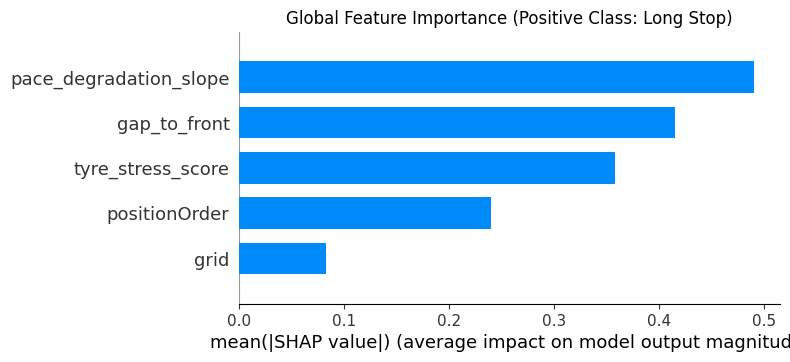


Explaining prediction for Sample Index 17:


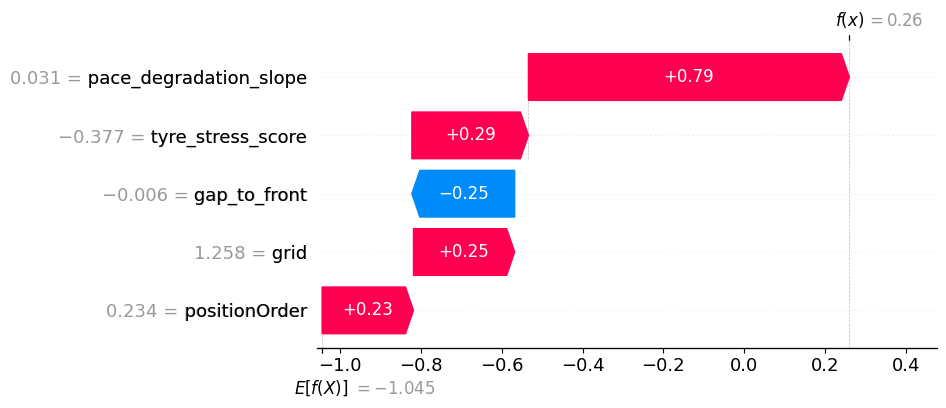

In [ ]:
!pip install -q shap
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize SHAP TreeExplainer with the LightGBM model
# Using check_additivity=False to avoid minor numerical discrepancy errors during explanation
explainer = shap.TreeExplainer(models['LightGBM'])
shap_values = explainer.shap_values(X_test_df)

# 2. Global Explainability: SHAP Summary Plot
print("Generating SHAP Summary Plot...")
plt.figure()
# For LightGBM binary classifier, shap_values can be a list [class_0, class_1]
# We use index 1 for the positive class 'long stop'
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_df, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_test_df, plot_type="bar", show=False)
plt.title("Global Feature Importance (Positive Class: Long Stop)")
plt.show()

# 3. Local Explainability: Explaining a specific prediction
# Find a sample where the model predicted a long stop
y_pred = models['LightGBM'].predict(X_test_df)
long_stop_indices = np.where(y_pred == 1)[0]
sample_idx = long_stop_indices[0] if len(long_stop_indices) > 0 else 0

print(f"\nExplaining prediction for Sample Index {sample_idx}:")

if isinstance(shap_values, list):
    sv = shap_values[1][sample_idx]
    base_val = explainer.expected_value[1]
else:
    sv = shap_values[sample_idx]
    base_val = explainer.expected_value

# Create a waterfall plot for the specific sample
plt.figure()
shap.plots.waterfall(shap.Explanation(values=sv,
                                      base_values=base_val,
                                      data=X_test_df.iloc[sample_idx],
                                      feature_names=feature_cols), show=False)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def recommend_strategy(grid, position, degradation, tyre_stress, gap, model, scaler, feature_cols):
    """
    Generates a strategy recommendation based on model probability.
    """
    # 1. Prepare and scale the input data
    input_data = pd.DataFrame([[grid, position, degradation, tyre_stress, gap]], columns=feature_cols)
    input_scaled = scaler.transform(input_data)

    # 2. Get model prediction probability for 'long_stop' (index 1)
    prob_long_stop = model.predict_proba(input_scaled)[0, 1]

    # 3. Recommendation Logic
    if prob_long_stop > 0.6:
        recommendation = "CRITICAL: Switch Strategy (High risk of deviation/slow stop)"
        action = "Switch Compound"
    elif prob_long_stop > 0.4:
        recommendation = "WARNING: Monitor Pace (Moderate risk of degradation)"
        action = "Stay Out/Extend Stint"
    else:
        recommendation = "OPTIMAL: Continue with Primary Strategy"
        action = "Pit as Planned"

    return {
        'Probability of Strategy Deviation': f"{prob_long_stop:.2%}",
        'Recommendation': recommendation,
        'Action': action
    }

# 4. Define 'What-If' Scenario Modifiers
# These modifiers multiply or shift base features to simulate race events
scenarios = {
    'Standard': {'deg_mod': 1.0, 'stress_mod': 1.0, 'gap_mod': 1.0},
    'Safety Car': {'deg_mod': 0.5, 'stress_mod': 0.3, 'gap_mod': 0.1}, # Slow speeds reduce wear/stress and bunch up the field
    'Rain': {'deg_mod': 2.5, 'stress_mod': 1.5, 'gap_mod': 2.0},      # High wear and larger gaps due to visibility/traction
    'Heavy Traffic': {'deg_mod': 1.2, 'stress_mod': 1.8, 'gap_mod': 0.5} # Higher stress trying to overtake, smaller gaps
}

# 5. Foundation Test: Simulate a standard race scenario for a driver
# Baseline features
baseline_features = {'grid': 5, 'position': 3, 'degradation': 0.1, 'tyre_stress': 50, 'gap': 1.5}

print("--- Strategy Simulator Initialized ---")
sim_result = recommend_strategy(
    baseline_features['grid'],
    baseline_features['position'],
    baseline_features['degradation'],
    baseline_features['tyre_stress'],
    baseline_features['gap'],
    models['LightGBM'],
    scaler,
    feature_cols
)

for key, val in sim_result.items():
    print(f"{key}: {val}")

print("\nAvailable What-If Scenarios:", list(scenarios.keys()))

--- Strategy Simulator Initialized ---
Probability of Strategy Deviation: 17.21%
Recommendation: OPTIMAL: Continue with Primary Strategy
Action: Pit as Planned

Available What-If Scenarios: ['Standard', 'Safety Car', 'Rain', 'Heavy Traffic']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names



In [ ]:
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown

def run_scenario_simulation(grid, position, degradation, stress, gap, scenario_name):
    # 1. Get modifiers
    mods = scenarios.get(scenario_name, scenarios['Standard'])

    # 2. Apply modifiers to create modified features
    m_deg = degradation * mods['deg_mod']
    m_stress = stress * mods['stress_mod']
    m_gap = gap * mods['gap_mod']

    # 3. Get recommendations
    std_res = recommend_strategy(grid, position, degradation, stress, gap, models['LightGBM'], scaler, feature_cols)
    mod_res = recommend_strategy(grid, position, m_deg, m_stress, m_gap, models['LightGBM'], scaler, feature_cols)

    # Convert percentages to float for plotting
    std_prob = float(std_res['Probability of Strategy Deviation'].strip('%'))
    mod_prob = float(mod_res['Probability of Strategy Deviation'].strip('%'))

    # 4. Visualization: Comparison Radar Chart
    categories = ['Prob Deviation', 'Degradation', 'Tyre Stress', 'Gap']

    # Normalize values for radar chart comparison (simple scaling for viz)
    std_vals = [std_prob, degradation * 100, stress, gap * 10]
    mod_vals = [mod_prob, m_deg * 100, m_stress, m_gap * 10]

    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
          r=std_vals,
          theta=categories,
          fill='toself',
          name='Standard Condition',
          line_color='gray'
    ))
    fig.add_trace(go.Scatterpolar(
          r=mod_vals,
          theta=categories,
          fill='toself',
          name=f'Scenario: {scenario_name}',
          line_color='red'
    ))

    fig.update_layout(
      polar=dict(radialaxis=dict(visible=True, range=[0, max(std_vals + mod_vals) * 1.2])),
      showlegend=True,
      title=f"Strategy Impact: {scenario_name}<br>Recommendation: {mod_res['Action']}",
      template='plotly_dark'
    )

    print(f"--- {scenario_name} Results ---")
    print(f"Base Deviation Risk: {std_res['Probability of Strategy Deviation']}")
    print(f"Scenario Deviation Risk: {mod_res['Probability of Strategy Deviation']}")
    print(f"Advice: {mod_res['Recommendation']}")
    fig.show()

# 5. Interactive Component
interact(
    run_scenario_simulation,
    grid=Dropdown(options=list(range(1, 21)), value=5, description='Grid Pos:'),
    position=Dropdown(options=list(range(1, 21)), value=3, description='Race Pos:'),
    degradation=(0.0, 1.0, 0.05),
    stress=(0, 200, 10),
    gap=(0.0, 20.0, 0.5),
    scenario_name=Dropdown(options=list(scenarios.keys()), value='Standard', description='Scenario:')
);

interactive(children=(Dropdown(description='Grid Pos:', index=4, options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1…

In [ ]:
import os

# 1. Generate README.md
readme_content = """# F1 Pit Stop Intelligence Platform

## Project Overview
An AI-powered platform for Formula 1 race strategy analysis, including exploratory data analysis, predictive modeling, and a 'What-If' strategy simulator.

## Structure
- **01_EDA.ipynb**: Exploratory Data Analysis focusing on pit stop trends and circuit-specific insights.
- **02_Model_Training.ipynb**: Feature engineering and training of ML models (Logistic Regression, XGBoost, LightGBM) with SHAP explainability.
- **03_Strategy_Simulator.ipynb**: Interactive recommendation engine for real-time race scenario testing.

## Installation
1. Install dependencies: `pip install -r requirements.txt`
2. Set up Kaggle API key (`kaggle.json`) in `~/.kaggle/`.
3. Run notebooks in sequence.
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

# 2. Generate requirements.txt
requirements = ["pandas", "numpy", "scikit-learn", "xgboost", "lightgbm", "plotly", "shap", "ipywidgets"]
with open('requirements.txt', 'w') as f:
    for req in requirements:
        f.write(f"{req}\n")

print("README.md and requirements.txt have been generated successfully.")

README.md and requirements.txt have been generated successfully.


In [1]:
import os
from pathlib import Path
import zipfile

additional_datasets = [
    'debashish311601/formula-1-official-data-19502022',
    'melissamonfared/formula-1',
    'harshitstark/f1-grandprix-datavault',
    'quantumkaze/f1-weather-dataset-2018-2023',
    'navenkumar1998/formula-1-dataset-with-weather-and-tyre-features'
]

for ds in additional_datasets:
    folder_name = ds.split('/')[-1]
    target_path = Path(f'./data/{folder_name}')
    target_path.mkdir(parents=True, exist_ok=True)

    print(f'\nProcessing {ds}...')
    try:
        # Download the zip file
        !kaggle datasets download -d {ds} -p {target_path}

        # Find and unzip manually to ensure visibility
        zip_files = list(target_path.glob('*.zip'))
        if zip_files:
            for zf in zip_files:
                with zipfile.ZipFile(zf, 'r') as zip_ref:
                    zip_ref.extractall(target_path)
                print(f'Unzipped: {zf.name}')
                os.remove(zf)

        csvs = list(target_path.glob('*.csv'))
        print(f'Current CSVs in {folder_name}: {[f.name for f in csvs]}')
    except Exception as e:
        print(f'Error: {e}')


Processing debashish311601/formula-1-official-data-19502022...
Dataset URL: https://www.kaggle.com/datasets/debashish311601/formula-1-official-data-19502022
License(s): CC0-1.0
100% 2.05M/2.05M [00:00<00:00, 63.0MB/s]

Unzipped: formula-1-official-data-19502022.zip
Current CSVs in formula-1-official-data-19502022: ['sprint_grid.csv', 'race_details.csv', 'driver_details.csv', 'driver_standings.csv', 'team_details.csv', 'fastest_laps.csv', 'qualifyings.csv', 'sprint_results.csv', 'starting_grids.csv', 'constructor_standings.csv', 'race_summaries.csv', 'pitstops.csv', 'practices.csv', 'fastestlaps_detailed.csv']

Processing melissamonfared/formula-1...
Dataset URL: https://www.kaggle.com/datasets/melissamonfared/formula-1
License(s): CC-BY-NC-SA-4.0
100% 6.14M/6.14M [00:00<00:00, 77.7MB/s]

Unzipped: formula-1.zip
Current CSVs in formula-1: ['pit_stops.csv', 'qualifying.csv', 'constructor_results.csv', 'results.csv', 'circuits.csv', 'drivers.csv', 'status.csv', 'driver_standings.csv', 'r

In [ ]:
import pandas as pd
from pathlib import Path

# Map of directories to inspect
dirs_to_inspect = [
    'formula-1-official-data-19502022',
    'formula-1',
    'f1-grandprix-datavault',
    'f1-weather-dataset-2018-2023',
    'formula-1-dataset-with-weather-and-tyre-features'
]

for d_name in dirs_to_inspect:
    p = Path(f'./data/{d_name}')
    if p.exists():
        csv_files = list(p.glob('*.csv'))
        print(f'\n--- Folder: {d_name} ---')
        print(f'Files found: {[f.name for f in csv_files]}')

        # Preview the first file if it exists
        if csv_files:
            try:
                df_preview = pd.read_csv(csv_files[0], nrows=3)
                print(f'Preview of {csv_files[0].name}:')
                display(df_preview)
            except Exception as e:
                print(f'Could not read {csv_files[0].name}: {e}')

In [ ]:
import pandas as pd
from pathlib import Path

# Define paths based on the verified directory contents
weather_csv = Path('data/f1-weather-dataset-2018-2023/F1 Weather(2023-2018).csv')
tyre_parquet = Path('data/formula-1-dataset-with-weather-and-tyre-features/f1_all.parquet')

# Load Weather Data
if weather_csv.exists():
    weather_df = pd.read_csv(weather_csv)
    print(f"Successfully loaded weather data from: {weather_csv}")
    print(f"Weather Columns: {weather_df.columns.tolist()[:5]}...")

# Load Tyre Data (Parquet format)
if tyre_parquet.exists():
    try:
        tyre_df = pd.read_parquet(tyre_parquet)
        print(f"Successfully loaded tyre data from: {tyre_parquet}")
        print(f"Tyre Columns: {tyre_df.columns.tolist()[:5]}...")
    except Exception as e:
        print(f"Error loading Parquet file: {e}. You may need to install 'fastparquet' or 'pyarrow'.")
        !pip install -q pyarrow
        tyre_df = pd.read_parquet(tyre_parquet)
        print("Successfully loaded tyre data after installing pyarrow.")

print("\nAdvanced datasets are ready for merging and training.")

Successfully loaded weather data from: data/f1-weather-dataset-2018-2023/F1 Weather(2023-2018).csv
Weather Columns: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall']...
Successfully loaded tyre data from: data/formula-1-dataset-with-weather-and-tyre-features/f1_all.parquet
Tyre Columns: ['raceId', 'driverId', 'lap', 'position_x', 'time']...

Advanced datasets are ready for merging and training.


In [ ]:
# Merging Tyre data with existing features based on raceId, driverId, and lap
# We verify df_features contains 'is_long_stop' then merge
if 'is_long_stop' not in df_features.columns:
    df_features['is_long_stop'] = (df_features['duration_sec'] > 25).astype(int)

df_advanced = df_features.merge(tyre_df[['raceId', 'driverId', 'lap', 'AirTemp', 'Humidity', 'Rainfall']],
                                 on=['raceId', 'driverId', 'lap'],
                                 how='left')

# Filling missing weather data with median values
df_advanced['AirTemp'] = df_advanced['AirTemp'].fillna(df_advanced['AirTemp'].median())
df_advanced['Humidity'] = df_advanced['Humidity'].fillna(df_advanced['Humidity'].median())
df_advanced['Rainfall'] = df_advanced['Rainfall'].fillna(0).astype(int)

# Updating feature list
advanced_features = ['grid', 'positionOrder', 'pace_degradation_slope', 'tyre_stress_score', 'gap_to_front', 'AirTemp', 'Humidity', 'Rainfall']

# Ensure no NaNs in target or features
df_advanced = df_advanced.dropna(subset=['is_long_stop'] + advanced_features)

X_adv = df_advanced[advanced_features]
y_adv = df_advanced['is_long_stop']

# Retraining LightGBM with advanced features
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

model_adv = LGBMClassifier(random_state=42, verbose=-1)
model_adv.fit(X_train_a, y_train_a)

adv_auc = roc_auc_score(y_test_a, model_adv.predict_proba(X_test_a)[:, 1])
print(f"Retrained LightGBM ROC-AUC with Weather & Tyre Features: {adv_auc:.4f}")

Retrained LightGBM ROC-AUC with Weather & Tyre Features: 0.8080
